数据形状: (3114, 17)
日期范围: 2013-07-02 00:00:00 到 2026-04-22 00:00:00
特征数量: 13
训练集: (3014, 13), 测试集: (100, 13)

开始测试不同参数组合...
参数1: C=1, gamma=scale, epsilon=0.01 → RMSE=1.6258, R²=0.6362
参数2: C=1, gamma=scale, epsilon=0.1 → RMSE=2.3265, R²=0.2551
参数3: C=10, gamma=scale, epsilon=0.01 → RMSE=2.2191, R²=0.3223
参数4: C=10, gamma=scale, epsilon=0.1 → RMSE=2.6090, R²=0.0632
参数5: C=100, gamma=scale, epsilon=0.01 → RMSE=5.8060, R²=-3.6390
参数6: C=100, gamma=scale, epsilon=0.1 → RMSE=5.7588, R²=-3.5640
参数7: C=100, gamma=0.01, epsilon=0.01 → RMSE=1.9752, R²=0.4631
参数8: C=100, gamma=0.1, epsilon=0.1 → RMSE=7.6711, R²=-7.0983
参数9: C=50, gamma=scale, epsilon=0.05 → RMSE=4.4398, R²=-1.7128
参数10: C=200, gamma=scale, epsilon=0.05 → RMSE=8.0265, R²=-7.8661

最优参数: C=1, gamma=scale, epsilon=0.01

=== 测试集评估结果 ===
RMSE: 1.625796
MAE: 1.176901
MAPE: 2.7847%
R²: 0.636242


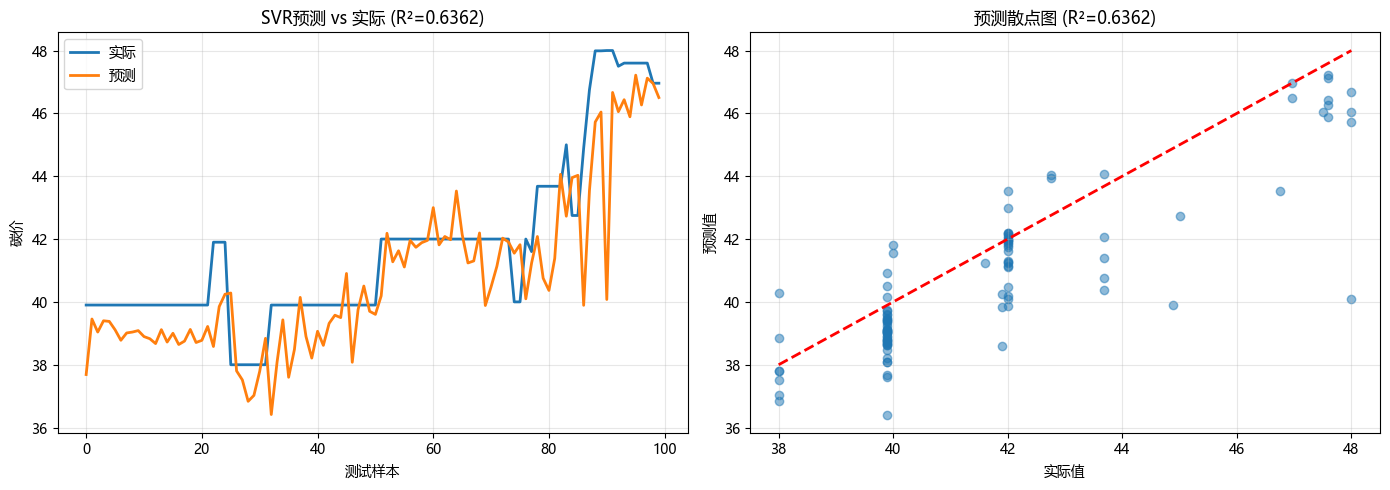


预测结果已保存至: test_predictions_svr.csv


In [21]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

SEED = 42
TEST_SIZE = 100

np.random.seed(SEED)

# ==================== 读取数据 ====================
df = pd.read_csv("shenzhen.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date", ascending=True).reset_index(drop=True)

for col in ["close"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ==================== 时间特征 ====================
df["Month"] = df["date"].dt.month

# ==================== 滞后特征（只用历史值） ====================
df["lag_1"] = df["close"].shift(1)
df["lag_2"] = df["close"].shift(2)
df["lag_3"] = df["close"].shift(3)
df["lag_5"] = df["close"].shift(5)

# ==================== 移动平均（修正：基于前一天的值） ====================
df["ma_5"] = df["close"].shift(1).rolling(window=5).mean()
df["ma_10"] = df["close"].shift(1).rolling(window=10).mean()

# ==================== 价格变化率（修正：昨天的变化率） ====================
df["price_change_lag1"] = df["close"].pct_change().shift(1)

# ==================== 波动率（修正：基于历史值） ====================
df["volatility_5"] = df["close"].shift(1).rolling(window=5).std()

# ==================== 沪深300（修正：只用历史值） ====================
hs300_path = "hs300_cache.csv"
if os.path.exists(hs300_path):
    hs300 = pd.read_csv(hs300_path)
    hs300["date"] = pd.to_datetime(hs300["date"])
    df = df.merge(hs300, on="date", how="left")
else:
    df["hs300_close"] = np.nan

df["hs300_close"] = df["hs300_close"].ffill().bfill()
if df["hs300_close"].isna().all():
    df["hs300_close"] = df["close"]

df["hs300_close_lag1"] = df["hs300_close"].shift(1)
df["hs300_change_lag1"] = df["hs300_close"].pct_change().shift(1)

# ==================== 燃料油（修正：只用历史值） ====================
fu_path = "fu0_cache.csv"
if os.path.exists(fu_path):
    fu_hist = pd.read_csv(fu_path)
    fu_hist["date"] = pd.to_datetime(fu_hist["date"])
    df = df.merge(fu_hist, on="date", how="left")
else:
    df["fu_close"] = np.nan

df["fu_close"] = df["fu_close"].ffill().bfill()
if df["fu_close"].isna().all():
    df["fu_close"] = df["close"]

df["fu_close_lag1"] = df["fu_close"].shift(1)
df["fu_change_lag1"] = df["fu_close"].pct_change().shift(1)

# ==================== 删除缺失值 ====================
df = df.dropna().reset_index(drop=True)

print(f"数据形状: {df.shape}")
print(f"日期范围: {df['date'].min()} 到 {df['date'].max()}")

# ==================== 特征列（全部使用历史值） ====================
feature_cols = [
    "Month",
    "lag_1", "lag_2", "lag_3", "lag_5",
    "ma_5", "ma_10",
    "price_change_lag1",
    "volatility_5",
    "hs300_close_lag1",
    "hs300_change_lag1",
    "fu_close_lag1",
    "fu_change_lag1"
]
target_col = "close"

X = df[feature_cols].values
y = df[target_col].values.reshape(-1, 1)

print(f"特征数量: {len(feature_cols)}")

# ==================== 时间顺序划分 ====================
if len(X) <= TEST_SIZE:
    raise ValueError(f"样本不足，总样本数={len(X)}，无法划分最后{TEST_SIZE}个样本做测试")

X_train, X_test = X[:-TEST_SIZE], X[-TEST_SIZE:]
y_train, y_test = y[:-TEST_SIZE], y[-TEST_SIZE:]

# ==================== 归一化（先划分再归一化，训练集fit，测试集transform） ====================
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train).ravel()
y_test_scaled = y_scaler.transform(y_test).ravel()

print(f"训练集: {X_train_scaled.shape}, 测试集: {X_test_scaled.shape}")

# ==================== 训练多个参数组合 ====================
param_sets = [
    {"C": 1, "gamma": "scale", "epsilon": 0.01},
    {"C": 1, "gamma": "scale", "epsilon": 0.1},
    {"C": 10, "gamma": "scale", "epsilon": 0.01},
    {"C": 10, "gamma": "scale", "epsilon": 0.1},
    {"C": 100, "gamma": "scale", "epsilon": 0.01},
    {"C": 100, "gamma": "scale", "epsilon": 0.1},
    {"C": 100, "gamma": 0.01, "epsilon": 0.01},
    {"C": 100, "gamma": 0.1, "epsilon": 0.1},
    {"C": 50, "gamma": "scale", "epsilon": 0.05},
    {"C": 200, "gamma": "scale", "epsilon": 0.05},
]

best_rmse = np.inf
best_params = None
best_model = None

print("\n开始测试不同参数组合...")
for i, params in enumerate(param_sets):
    svr = SVR(kernel='rbf', C=params["C"], gamma=params["gamma"], 
              epsilon=params["epsilon"], cache_size=500)
    svr.fit(X_train_scaled, y_train_scaled)
    
    y_pred_scaled = svr.predict(X_test_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
    y_true = y_scaler.inverse_transform(y_test_scaled.reshape(-1, 1))
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"参数{i+1}: C={params['C']}, gamma={params['gamma']}, epsilon={params['epsilon']} "
          f"→ RMSE={rmse:.4f}, R²={r2:.4f}")
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params
        best_model = svr

print(f"\n最优参数: C={best_params['C']}, gamma={best_params['gamma']}, epsilon={best_params['epsilon']}")

# ==================== 最终预测 ====================
y_pred_scaled = best_model.predict(X_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_true = y_scaler.inverse_transform(y_test_scaled.reshape(-1, 1))

# ==================== 评估指标 ====================
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100
r2 = r2_score(y_true, y_pred)

print("\n=== 测试集评估结果 ===")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"MAPE: {mape:.4f}%")
print(f"R²: {r2:.6f}")

# ==================== 可视化 ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(y_true, label="实际", linewidth=2)
axes[0].plot(y_pred, label="预测", linewidth=2)
axes[0].set_title(f"SVR预测 vs 实际 (R²={r2:.4f})")
axes[0].set_xlabel("测试样本")
axes[0].set_ylabel("碳价")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_true, y_pred, alpha=0.5)
axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', linewidth=2)
axes[1].set_title(f"预测散点图 (R²={r2:.4f})")
axes[1].set_xlabel("实际值")
axes[1].set_ylabel("预测值")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== 保存结果 ====================
errors = (y_pred - y_true).flatten()
save_path = "test_predictions_svr.csv"
result_df = pd.DataFrame({
    "actual_close": y_true.flatten(),
    "predicted_close": y_pred.flatten(),
    "error": errors,
    "abs_error": np.abs(errors)
})

result_df.to_csv(save_path, index=False)
print(f"\n预测结果已保存至: {save_path}")